# 04_07 Regression - DecisionTreeRegressor

Train and evaluate DecisionTreeRegressor.


[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]

- Muc tieu nghiep vu: Train DecisionTreeRegressor va xem hieu nang du doan tren test set.
- Muc tieu ky thuat: Hien thi metric table + scatter actual/prediction + residual histogram.


26/03/31 23:05:51 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 23:05:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 23:05:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/31 23:05:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 23:05:52 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/31 23:05:52 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/31 23:05:52 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


{'model_family': 'regression', 'model_name': 'DecisionTreeRegressor', 'val_rmse': 204.56864502823456, 'val_mae': 94.67978342561123, 'val_r2': 0.11295183880860193, 'rmse': 224.1763441456517, 'mae': 94.75828524154285, 'r2': 0.09442668014305977, 'test_rmse': 224.1763441456517, 'test_mae': 94.75828524154285, 'test_r2': 0.09442668014305977, 'train_rows': 69077, 'val_rows': 14728, 'test_rows': 14861}


,model_family,model_name,val_rmse,val_mae,val_r2,rmse,mae,r2,test_rmse,test_mae,test_r2,train_rows,val_rows,test_rows
0,regression,DecisionTreeRegressor,204.568645,94.679783,0.112952,224.176344,94.758285,0.094427,224.176344,94.758285,0.094427,69077,14728,14861


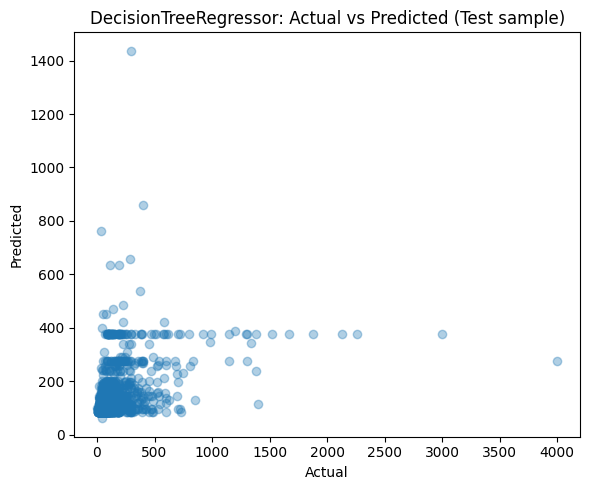

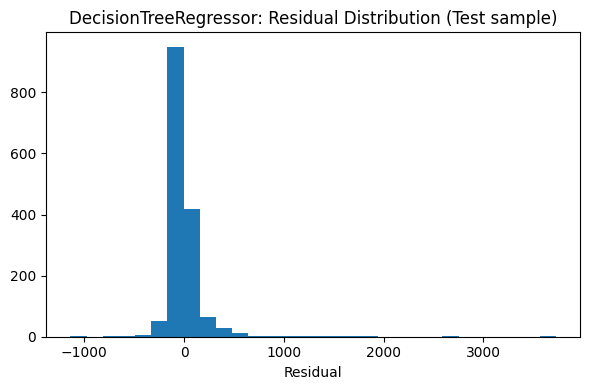

427

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
spark=(SparkSession.builder.appName('04_07_dt_reg').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate()) # type: ignore
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'regression'/'decision_tree'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df=spark.read.parquet(str(FEATURE_DIR/'regression_train')).select('order_id','label','features').dropna()
val_df=spark.read.parquet(str(FEATURE_DIR/'regression_val')).select('order_id','label','features').dropna()
test_df=spark.read.parquet(str(FEATURE_DIR/'regression_test')).select('order_id','label','features').dropna()
dt=DecisionTreeRegressor(featuresCol='features',labelCol='label',maxDepth=14,seed=42)
m=dt.fit(train_df)
pred_val=m.transform(val_df)
pred_test=m.transform(test_df)
val_rmse=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='rmse').evaluate(pred_val)
val_mae=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='mae').evaluate(pred_val)
val_r2=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='r2').evaluate(pred_val)
test_rmse=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='rmse').evaluate(pred_test)
test_mae=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='mae').evaluate(pred_test)
test_r2=RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName='r2').evaluate(pred_test)
metrics={'model_family':'regression','model_name':'DecisionTreeRegressor','val_rmse':float(val_rmse),'val_mae':float(val_mae),'val_r2':float(val_r2),'rmse':float(test_rmse),'mae':float(test_mae),'r2':float(test_r2),'test_rmse':float(test_rmse),'test_mae':float(test_mae),'test_r2':float(test_r2),'train_rows':train_df.count(),'val_rows':val_df.count(),'test_rows':test_df.count()}
print(metrics)
display(pd.DataFrame([metrics]))
sample_pdf=pred_test.select('label','prediction').sample(False,0.1,42).toPandas()
if not sample_pdf.empty:
    sample_pdf['residual']=sample_pdf['label']-sample_pdf['prediction']
    plt.figure(figsize=(6,5))
    plt.scatter(sample_pdf['label'], sample_pdf['prediction'], alpha=0.35)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('DecisionTreeRegressor: Actual vs Predicted (Test sample)')
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(6,4))
    plt.hist(sample_pdf['residual'], bins=30)
    plt.title('DecisionTreeRegressor: Residual Distribution (Test sample)')
    plt.xlabel('Residual')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'regression_decision_tree.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')